# Module 03 : Visualisation

Au module 02, nous avons appris à charger, nettoyer, transformer et analyser simplement nos données. Nous avions notamment obtenu ce tableau en réponse (partielle) à notre question de recherche (*Est-ce que le télétravail contribue à une meilleure performance des entreprises ?*) :

```
             ca_par_salarie_moyen  rentabilite_moyenne  satisfaction_rh_moyenne
teletravail
0                       149.8                  0.071                     6.55
1                       151.9                  0.099                     7.00
```

Ce tableau contient une information intéressante : les entreprises ayant recours au télétravail présentent ici, en moyenne, un chiffre d'affaires par salarié, une rentabilité et une satisfaction RH légèrement supérieurs. Ces chiffres peuvent être **difficiles à interpréter d'un coup d'œil**, surtout pour un lecteur pressé (un relecteur d'article, un collègue, un jury de thèse). Il faut donc prendre quelques secondes pour comparer les différentes valeurs et comprendre les écarts. Pour cela, nous aurons besoin d'un graphique qui permettra de rendre visuellement ces différences.

Dans ce module, nous allons alors **apprendre à choisir une représentation adaptée à une question de recherche et à un type de données**.

**Avant de commencer**, consultez le [README de ce module](README.md).

Ce module complète le tronc commun consacré **à la préparation et à l'exploration des données**. À son terme, vous saurez non seulement **manipuler une base de données avec `pandas`, choisir et produire des visualisations adaptées** à vos questions de recherche.


## 1. Choisir le bon graphique

### 1.1. Introduction

Avant d'écrire la moindre ligne de code, posez-vous une question simple : "**Qu'est-ce que je veux montrer ?**". Le choix du graphique dépend principalement de la relation que vous souhaitez mettre en évidence. Par exemple, voici quelques situations fréquentes en recherche :

| Ce que vous voulez montrer                          | Exemple                               | Graphique adapté                     |
| --------------------------------------------------- | ------------------------------------- | ------------------------------------ |
| Comparer des catégories                             | Télétravail vs absence de télétravail | **Graphique en barres (diagramme en bâtons)**              |
| Montrer une évolution dans le temps                 | CA de 2019 à 2023                     | **Graphique en ligne (graphique linéaire)**               |
| Observer la distribution d'une variable             | Distribution de la rentabilité        | **Histogramme**                      |
| Comparer la distribution entre plusieurs groupes    | Rentabilité avec/sans télétravail     | **Boxplot**                          |
| Étudier la relation entre deux variables numériques | Effectifs et chiffre d'affaires       | **Nuage de points** (*scatter plot*) |

Il n'existe donc pas de « meilleur graphique » dans l'absolu. Le bon graphique est celui qui permet **de faire ressortir le message que vos données doivent transmettre**.

Supposons par exemple que nous voulions simplement comparer la rentabilité moyenne des entreprises selon qu'elles pratiquent ou non le télétravail. Nous avons deux catégories :

```
Pas de télétravail
Télétravail
```

Un graphique en barres est alors approprié :

```
Rentabilité moyenne
        │
   10 % ┤             █
        │             █
    8 % ┤             █
        │             █
    6 % ┤    █        █
        │    █        █
    4 % ┤    █        █
        │    █        █
    0 % ┼──────────────────
             Non       Oui
             télétravail
```

Le lecteur peut immédiatement voir que la rentabilité moyenne est plus élevée dans le groupe « télétravail ».

**Mais attention !** Un graphique peut aussi induire en erreur. Choisir un graphique ne consiste pas uniquement à opter pour celui qui « fonctionne ». La représentation choisie peut également suggérer une relation qui n'existe pas. Imaginons, par exemple, que nous voulions comparer la rentabilité moyenne de plusieurs secteurs :

```
Industrie
Commerce
Santé
Technologies
```

Un graphique en ligne pourrait relier ces catégories :

```
Industrie ─── Commerce ─── Santé ─── Technologies
```

Le problème est que ces secteurs ne constituent pas une succession naturelle. La ligne donne l'impression que nous observons une évolution d'un secteur vers l'autre, alors qu'il s'agit de différentes catégories. Un graphique en barres serait donc plus approprié.

> Retenez que le choix d'un graphique n'est pas seulement une question esthétique. Il influence la manière dont le lecteur interprète vos données.

### 1.2. Le type de variable

Pour choisir correctement une visualisation, il est aussi utile d'identifier le type de variable que l'on souhaite représenter.

#### 1.2.1. Variable catégorielle

Une variable catégorielle (ou variable qualitative) est une caractéristique qui ne se mesure pas avec un nombre, mais qui classe les éléments dans des groupes ou des catégories distincts. Exemple :

```
secteur
région
télétravail
```

Ici, on cherchera à comparer les catégories.

→ **Graphique en barres**, par exemple.

#### 1.2.2. Variable numérique

Elle prend des valeurs numériques :

```
effectifs
chiffre_affaires_keur
rentabilite
satisfaction_rh
```

On peut notamment chercher à :

- observer sa distribution ;
- comparer ses valeurs entre groupes ;
- étudier sa relation avec une autre variable.

→ **Histogramme, boxplot, nuage de points, etc.**

#### 1.2.3. Variable temporelle

Elle représente une date ou une période :

```
2019
2020
2021
2022
2023
```

Ici, on va chercher à observer une évolution dans le temps.

→ **Graphique en ligne**, par exemple.

### 1.3. Les trois bibliothèques que nous allons utiliser

Python dispose de nombreuses bibliothèques qui permettent de créer des visualisations. Dans ce module, nous allons principalement en utiliser trois.

#### 1.3.1. `matplotlib`

`matplotlib` est la bibliothèque de base de la visualisation en Python. Elle offre un contrôle très précis sur les graphiques, mais nécessite parfois davantage de code.


In [1]:
import pandas as pd # On importe pandas pour la manipulation de données

import matplotlib.pyplot as plt

Si vous avez remarqué, nous avons importé  le sous-module `pyplot` de Matplotlib sous l'alias conventionnel `plt` : `import matplotlib.pyplot as plt`. En effet, `pyplot` contient toutes les méthodes dont nous aurons besoin pour créer des graphiques et les styliser.

#### 1.3.2. `seaborn`

`seaborn` est construite sur `matplotlib`. Elle simplifie la création de nombreux graphiques statistiques et produit généralement des visualisations adaptées à l'analyse de données avec relativement peu de code.

In [2]:
import seaborn as sns

#### 1.3.3. `plotly`

`plotly` permet notamment de créer des graphiques interactifs. Le lecteur peut par exemple :

- déplacer la souris sur un point pour obtenir sa valeur ;
- zoomer ;
- masquer certaines séries ;
- explorer les données directement dans le graphique.


In [3]:
import plotly.express as px

Pour résumer :

| Bibliothèque | Utilisation                              |
| ------------ | ---------------------------------------------- |
| `matplotlib` | Contrôle et personnalisation                   |
| `seaborn`    | Visualisations statistiques faciles à produire |
| `plotly`     | Visualisations interactives                    |


Dans ce cours, nous commencerons principalement avec `matplotlib` et `seaborn`, puis nous découvrirons plus tard `plotly` pour l'interactivité.

### 1.4. Préparer les données

Après avoir **importé les bibliothèques** dont nous aurons besoin, nous allons **charger notre jeu de données** :

In [4]:

df = pd.read_csv("../../assets/datasets/entreprises_panel.csv")


Vérifions rapidement son contenu :

In [5]:
df.head(3)

,entreprise_id,annee,secteur,region,annee_creation,teletravail,effectifs,chiffre_affaires_keur,rentabilite,satisfaction_rh
0,E001,2019,Industrie,Occitanie,2018,1,529,115830.2,0.1706,7.7
1,E001,2020,Industrie,Occitanie,2018,1,590,125110.5,0.1497,6.7
2,E001,2021,Industrie,Occitanie,2018,1,610,123760.0,0.1594,5.5


> **Pourquoi recommencer avec `read_csv()` ?**
> Même si nous avons déjà travaillé avec ce jeu de données au module précédent, chaque notebook est indépendant. Avant de commencer toute analyse, il faut donc préparer l'environnement de travail et charger les données dont on aura besoin, dès le début.


## 2. Matplotlib : les bases

`matplotlib` est l'une des principales bibliothèques Python pour créer des graphiques. Nous allons commencer par les éléments essentiels : créer une figure, tracer des données, puis ajouter progressivement les informations nécessaires pour rendre le graphique compréhensible.

### 2.1. Anatomie d'une figure

Pour utiliser `matplotlib`, vous devez maîtriser ces deux notions essentielles :

- **`Figure`** : l'ensemble de la figure, c'est-à-dire la fenêtre ou l'image qui contient le ou les graphiques.
- **`Axes`** : un graphique individuel à l'intérieur de la figure.

> **Attention !** ans Matplotlib, un objet `Axes` ne désigne pas seulement l'axe X ou l'axe Y. Il désigne l'ensemble du graphique, avec ses axes, son titre, ses données, etc.

Pour créer une figure et un graphique, on utilise généralement :


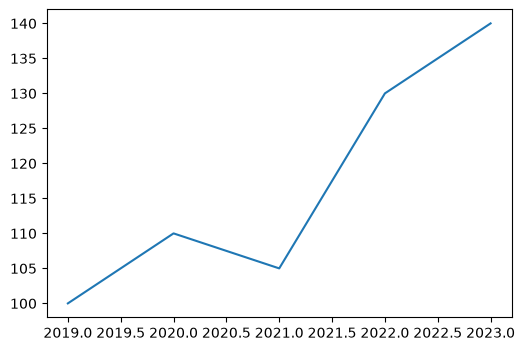

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    [2019, 2020, 2021, 2022, 2023],
    [100, 110, 105, 130, 140]
)

plt.show()

Ici :

- `fig` représente la figure entière ;
- `ax` représente le graphique dans cette figure ;
- `figsize=(6, 4)` définit la largeur et la hauteur de la figure, en pouces.

On peut ensuite utiliser `ax` pour tracer nos données :

- le premier ensemble de valeurs correspond à l'axe X : 2019 → 2020 → 2021 → 2022 → 2023 ;
- le deuxième correspond aux valeurs à représenter sur l'axe Y : 100 → 110 → 105 → 130 → 140

Enfin, `ax.plot()` relie ces différents points pour former une courbe.

**Pourquoi utiliser fig, `ax = plt.subplots()` ?** Pour un graphique très simple, on pourrait également écrire :

```python
plt.plot(...)
```

Cette syntaxe fonctionne. Cependant, nous allons privilégier :

```python
fig, ax = plt.subplots()
```

car cette manière de travailler devient beaucoup plus pratique lorsque nous voulons :

- personnaliser un graphique ;
- ajouter plusieurs courbes ;
- créer plusieurs graphiques dans une même figure ;
- contrôler précisément les différents éléments du graphique.

> **Bonne habitude.** Même lorsque votre graphique est simple, prenez l'habitude de travailler avec `fig` et `ax`. Cela vous évitera de devoir changer de méthode quand vos graphiques deviendront plus complexes.

### 2.2. Tracer une évolution dans le temps

Reprenons notre question de recherche : *Est-ce que le télétravail contribue à une meilleure performance des entreprises ?* Nous pouvons commencer par observer l'évolution du chiffre d'affaires moyen au cours du temps, en distinguant les entreprises selon leur pratique du télétravail.

Avant de tracer le graphique, nous devons préparer les données.


In [7]:
evolution = df.groupby(["annee", "teletravail"])["chiffre_affaires_keur"].mean().unstack()
evolution


teletravail,0,1
annee,,
2019,38438.520000,37190.651064
2020,39980.723529,39359.045652
2021,41759.914706,40880.100000
2022,43093.114286,42650.154348
2023,44386.126471,44110.240426


**Que fait `.unstack()` ?**

Cette méthode mérite une petite explication. La méthode `groupby()` crée des groupes selon deux variables :

```python
df.groupby(["annee", "teletravail"])
```

Le résultat est donc organisé selon deux niveaux :

```
année
   └── télétravail
```

On utilise alors `.unstack()` pour transformer le deuxième niveau (`teletravail`) en colonnes.

```
année       sans télétravail    avec télétravail
2019              ...                ...
2020              ...                ...
2021              ...                ...
```

Cette organisation est pratique pour tracer deux courbes.

**Construire le graphique**. Avec le code ci-après, nous allons donc :

- créer notre figure ;
- tracer les deux séries ;
- puis ajouter les informations nécessaires à la lecture du graphique.


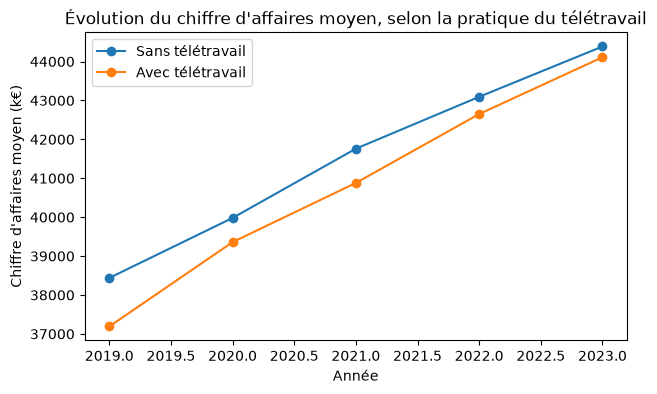

In [8]:
# On créé la figure
fig, ax = plt.subplots(figsize=(7, 4))

# On trace les deux séries
ax.plot(evolution.index, evolution[0], marker="o", label="Sans télétravail")
ax.plot(evolution.index, evolution[1], marker="o", label="Avec télétravail")

# On ajoute les informations nécessaires à la lecture du graphique
ax.set_xlabel("Année")
ax.set_ylabel("Chiffre d'affaires moyen (k€)")
ax.set_title("Évolution du chiffre d'affaires moyen, selon la pratique du télétravail")
ax.legend()

plt.show()


**Décortiquons le code** :

La fonction `ax.plot(x, y)` indique à Matplotlib ce qu'il y a à représenter. Dans notre exemple :

- `evolution.index` fournit les années → axe X et `evolution[0]` fournit les chiffres d'affaires moyens → axe Y, pour le label "Sans télétravail" ;
- `evolution.index` fournit les années → axe X et `evolution[1]` fournit les chiffres d'affaires moyens → axe Y, pour le label "Avec télétravail" ;

Nous avons utilisé deux paramètres :

- `marker="o"` pour ajouter un point à chaque observation. C'est pratique lorsque nous voulons faire apparaître clairement les valeurs correspondant à chaque année.
- `label="Sans télétravail"` (ou "Avec télétravail") pour donner un nom à la série. Ce nom sera utilisé dans la légende.

Pour ajouter des informations au graphique, les instructions `ax.set_xlabel("Année")` et `ax.set_ylabel("Chiffre d'affaires moyen (k€)")` permettent respectivement de donner un nom à l'axe `X` et à l'axe `Y`. Ensuite, `ax.set_title("...")` ajoute un titre au graphique. Et `ax.legend()` affiche la légende à partir des labels que nous avons définis dans `ax.plot()`.

> Un graphique doit pouvoir être compris sans avoir à retourner au code pour deviner ce que représentent ses axes ou ses séries. Les titres, labels et légendes ne sont donc pas de simples éléments décoratifs.


Si vous observez bien le graphique, vous verrez que sur l'axe X, les années sont : 2019.0, 2019.5, 2020.0, 2020.5... Cela s'explique par le fait que Matplotlib traite l'axe X comme une échelle numérique continue. Il choisit automatiquement les graduations qu'il juge adaptées. Comme l'espace entre 2019 et 2020 est assez petit, il peut décider d'afficher :

```
2019.0   2019.5   2020.0   2020.5   2021.0 ...
```

**La solution ?** Dans notre cas, nous voulons afficher une graduation pour chaque année. On peut donc demander explicitement à Matplotlib quelles graduations utiliser avec `ax.set_xticks(evolution.index)`.


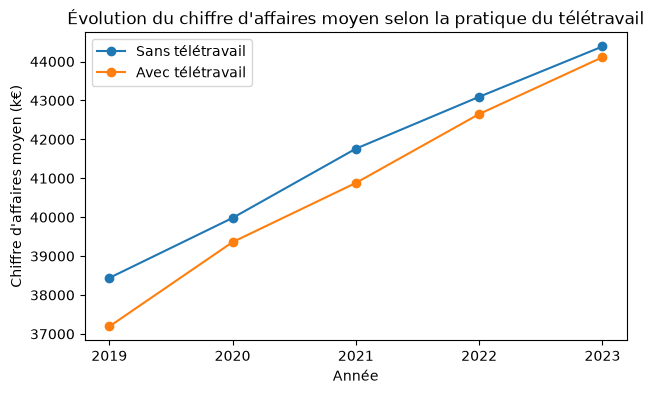

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    evolution.index,
    evolution[0],
    marker="o",
    label="Sans télétravail"
)

ax.plot(
    evolution.index,
    evolution[1],
    marker="o",
    label="Avec télétravail"
)

ax.set_xticks(evolution.index)

ax.set_xlabel("Année")
ax.set_ylabel("Chiffre d'affaires moyen (k€)")
ax.set_title(
    "Évolution du chiffre d'affaires moyen selon la pratique du télétravail"
)
ax.legend()

plt.show()

### 2.3. Visualiser une distribution avec un histogramme

Jusqu'ici, nous avons utilisé un graphique en ligne pour montrer une évolution dans le temps. Mais nous pouvons aussi nous poser une autre question : *Comment les valeurs de rentabilité sont-elles réparties dans notre échantillon ?* Un histogramme permet de répondre à cette question. Le code suivant va nous permettre de créer un histogramme avec `hist()` :

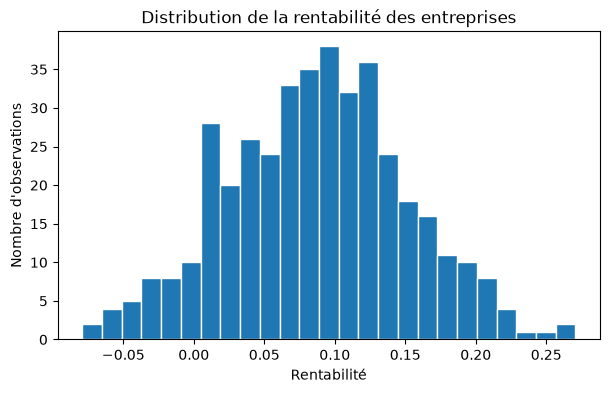

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df["rentabilite"], bins=25, edgecolor="white")

ax.set_xlabel("Rentabilité")
ax.set_ylabel("Nombre d'observations")
ax.set_title("Distribution de la rentabilité des entreprises")

plt.show()


#### 2.3.1. Comment fonctionne un histogramme ?

Contrairement à un graphique en barres, un histogramme ne compare pas des catégories. Il regroupe les valeurs numériques en intervalles, puis indique combien d'observations appartiennent à chaque intervalle. Par exemple, si nos rentabilités vont de *0 à 0,25*, les valeurs peuvent être regroupées en intervalles comme :

```
0,00 – 0,01
0,01 – 0,02
0,02 – 0,03
...
```
La hauteur de chaque barre indique alors combien d'observations se trouvent dans cet intervalle.

#### 2.3.2. Le paramètre bins

Dans notre exemple, `bins=25` demande à Matplotlib de répartir les données en **25 intervalles**. Vous l'aurez compris, le choix du nombre de bins aura un impact sur l'apparence du graphique :

- trop peu d'intervalles → la distribution peut être trop simplifiée ;
- trop d'intervalles → le graphique peut devenir difficile à lire.

Il n'y a pas un nombre de bins universellement correct. Le choix dépend notamment de la quantité de données et de l'objectif de la visualisation.

> **Attention** `bins=25` ne signifie pas que l'axe X affichera 25 valeurs. Le paramètre bins indique à Matplotlib en combien d'intervalles il doit répartir les observations pour construire les barres. Les graduations visibles sur l'axe X sont choisies automatiquement et peuvent être moins nombreuses.

#### 2.3.3. `edgecolor`

Le paramètre edgecolor définit la couleur du contour des barres de l'histogramme. Ici, `edgecolor="white"` demande à Matplotlib de dessiner un contour blanc autour de chaque barre.Cela permet de mieux distinguer les différentes barres, surtout lorsqu'elles sont côte à côte.`edgecolor` signifie littéralement couleur du bord (edge color).


**À vous de jouer**

Tracez maintenant un histogramme de la variable `satisfaction_rh`. Votre graphique doit :

- utiliser `bins=15` ;
- avoir "Satisfaction RH" comme label de l'axe X ;
- avoir "Nombre d'observations" comme label de l'axe Y ;
- avoir un titre permettant de comprendre ce que représente le graphique.


In [11]:
# Votre code ici


## 3. Seaborn, pour créer des graphiques statistiques de façon simple, rapide et élégante.

`seaborn` est une bibliothèque de visualisation construite au-dessus de `matplotlib`. Elle propose des fonctions, prêtes à l'emploi, spécialement conçues pour les graphiques statistiques. Elle permet de produire en quelques lignes un graphique qui demanderait davantage de travail avec `matplotlib`. Il faut aussi noter que Seaborn fonctionne naturellement avec les `DataFrames` `pandas`. Au lieu de lui fournir directement des listes de valeurs, on peut lui indiquer le `DataFrame` et les noms des colonnes à représenter.

Par exemple, le code suivant :

```python
sns.boxplot(data=df, x="teletravail", y="rentabilite")
```

se lit presque de la sorte : « *Dans `df`, représente `rentabilite` en fonction de `teletravail` sous la forme d'un `boxplot`.* »

Dans cette partie, nous allons découvrir trois utilisations particulièrement utiles en recherche :

- comparer des distributions avec un `boxplot` ;
- représenter des relations entre variables avec une `heatmap` ;
- comparer plusieurs groupes grâce à `hue`.

### 3.1. Boxplot : comparer des distributions entre groupes

Au module 02, nous avons principalement comparé des moyennes. Mais une moyenne ne suffit pas toujours. Deux groupes peuvent avoir exactement la même moyenne tout en ayant des distributions différentes. Le `boxplot` permet alors de comparer la distribution d'une variable entre plusieurs groupes.

Par exemple, nous pouvons comparer la rentabilité des entreprises selon leur pratique du télétravail.

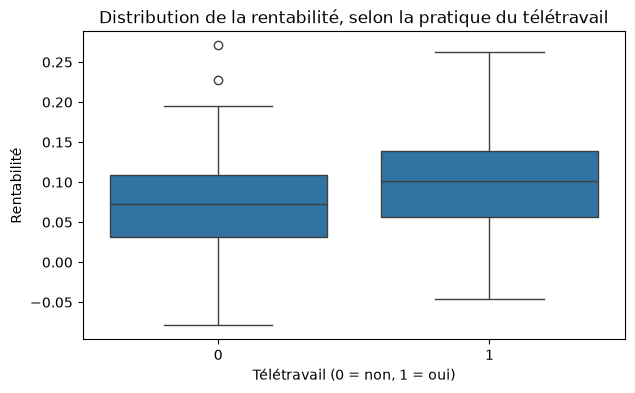

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(data=df, x="teletravail", y="rentabilite", ax=ax)

ax.set_xlabel("Télétravail (0 = non, 1 = oui)")
ax.set_ylabel("Rentabilité")
ax.set_title("Distribution de la rentabilité, selon la pratique du télétravail")

plt.show()


#### 3.1.1. Que fait `sns.boxplot()` ?

Les trois principaux paramètres sont :

- `data=df` indique le DataFrame contenant les données ;
- `x="teletravail"` indique la variable utilisée pour former les groupes sur l'axe X ;
- `y="rentabilite"` indique la variable numérique dont nous voulons comparer la distribution.

Ici, nous avons deux groupes :

- `0` = sans télétravail ;
- `1` = avec télétravail.

On demande donc à Seaborn : « *Compare la distribution de la rentabilité entre les entreprises sans télétravail et celles avec télétravail.* »

#### 3.1.2. Comment lire un `boxplot` ?

Un `boxplot` résume la distribution d'une variable à l'aide de plusieurs éléments.

- La ligne au milieu de la boîte représente la médiane.
- Le bas et le haut de la boîte correspondent respectivement au premier et au troisième quartile.
- La boîte contient donc les 50 % d'observations situées au milieu de la distribution.
- Les moustaches indiquent l'étendue des valeurs considérées comme habituelles selon la règle utilisée par Seaborn.
- Les points situés au-delà peuvent représenter des valeurs atypiques (outliers).

Nous étudierons les quartiles, la médiane et les valeurs atypiques plus précisément dans le module consacré aux statistiques.

**Pourquoi utiliser un boxplot plutôt qu'une moyenne ?** Parce qu'il permet de voir non seulement le niveau central d'un groupe, mais aussi la dispersion des observations et l'éventuelle présence de valeurs atypiques (*outliers*).

### 3.2. Heatmap : visualiser une matrice de corrélations

Seaborn est également très pratique pour représenter des tableaux de données sous forme de cartes de chaleur (heatmaps). Prenons quelques variables numériques :


In [13]:
# Variables numériques
colonnes_numeriques = ["effectifs", "chiffre_affaires_keur", "rentabilite", "satisfaction_rh"]

# On calcule leur matrice de corrélations
correlations = df[colonnes_numeriques].corr()
correlations


,effectifs,chiffre_affaires_keur,rentabilite,satisfaction_rh
effectifs,1.000000,0.851907,0.048235,0.056959
chiffre_affaires_keur,0.851907,1.000000,0.043875,0.081565
rentabilite,0.048235,0.043875,1.000000,0.162839
satisfaction_rh,0.056959,0.081565,0.162839,1.000000


`.corr()` calcule le coefficient de corrélation entre chaque paire de colonnes numériques (vu en détail au module 04). Le tableau est exploitable, mais il est difficile d'en percevoir rapidement les tendances. Une heatmap permet de représenter ces valeurs visuellement :


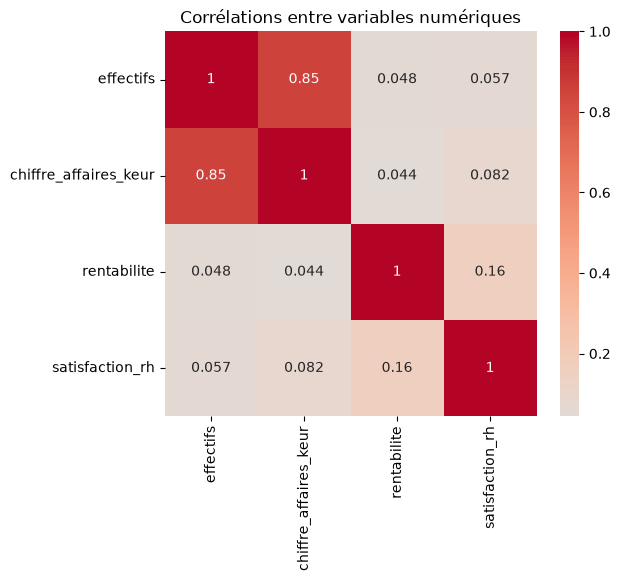

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(correlations, annot=True, cmap="coolwarm", center=0, ax=ax)

ax.set_title("Corrélations entre variables numériques")

plt.show()


**Décortiquons les paramètres**

- `annot=True` affiche la valeur numérique de chaque corrélation directement dans la case. Sans `annot=True`, on aurait uniquement les couleurs.
- `cmap="coolwarm"` choisit la palette de couleurs utilisée pour représenter les valeurs.
- `center=0` indique que la valeur `0` doit se trouver au centre de la palette.

Ces paramètres sont utiles pour une matrice de corrélations, puisque :

- les valeurs proches de `-1` indiquent une corrélation négative forte ;
- les valeurs proches de `0` indiquent une corrélation faible ou nulle ;
- les valeurs proches de `+1` indiquent une corrélation positive forte.

Nous étudierons précisément la corrélation au module 04.

> **Attention.** Corrélation ne signifie pas causalité. Une forte corrélation entre deux variables ne permet pas, à elle seule, de conclure que l'une provoque l'autre.

### 3.3. Comparer plusieurs groupes avec `hue`

Une autre fonctionnalité assez intéressante utile avec Seaborn est le paramètre `hue`. Il permet d'ajouter une troisième dimension catégorielle au graphique en utilisant une couleur différente pour chaque catégorie. Par exemple, nous pouvons comparer le chiffre d'affaires moyen selon le secteur et selon la pratique du télétravail :

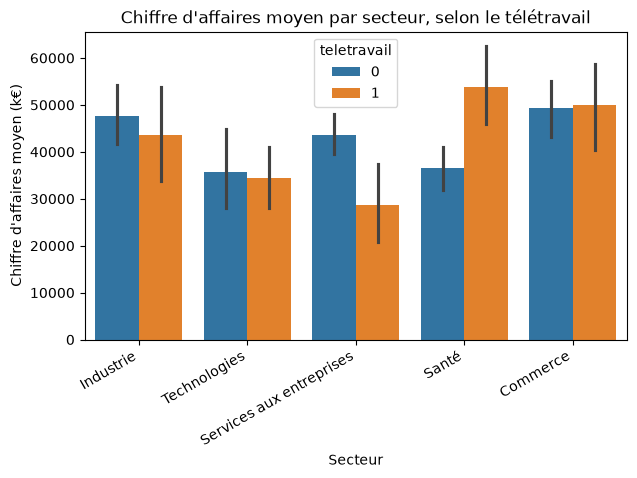

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=df, x="secteur", y="chiffre_affaires_keur", hue="teletravail", ax=ax)

ax.set_xlabel("Secteur")
ax.set_ylabel("Chiffre d'affaires moyen (k€)")
ax.set_title("Chiffre d'affaires moyen par secteur, selon le télétravail")

plt.xticks(rotation=30, ha="right")  # incline les labels du secteur pour éviter qu'ils se chevauchent

plt.show()


Dans l'instruction :

```python
sns.barplot(data=df, x="secteur", y="chiffre_affaires_keur", hue="teletravail", ax=ax)
```

`hue="teletravail"` ajoute automatiquement une couleur par valeur de télétravail, avec la légende correspondante. Avec ce paramètre, on demande de comparer le chiffre d'affaires moyen entre les secteurs et de distinguer les entreprises selon leur pratique du télétravail. Seaborn crée alors automatiquement une série différente pour chaque valeur de `teletravail`, ainsi qu'une légende qui permet de les identifier. C'est beaucoup plus simple que de construire manuellement les différentes séries avec Matplotlib.

**Les labels des secteurs**. Les noms des secteurs peuvent être relativement longs. Ils risquent donc de se chevaucher. Cette instruction `plt.xticks(rotation=30, ha="right")` fait pivoter les labels de l'axe X de **30 degrés** et les aligne vers la droite. Cela améliore la lisibilité du graphique.

**À vous de jouer**. À partir de l'exemple précédent, créez maintenant un `boxplot` qui permet de comparer la distribution de `satisfaction_rh` entre les différents secteurs. Votre graphique doit :

- utiliser `secteur` sur l'axe `X` ;
- utiliser `satisfaction_rh` sur l'axe `Y` ;
- avoir un titre explicite ;
- nommer les deux axes ;
- incliner les labels de l'axe X si nécessaire.


In [16]:
# Votre code ici


## 4. Plotly, pour des graphiques interactifs

Jusqu'à présent, nous avons utilisé `matplotlib` et `seaborn` pour produire des graphiques statiques. Plotly permet d'aller plus loin en produisant des graphiques interactifs de qualité professionnelle. Avec ces derniers, le lecteur peut entre autres :

- survoler une observation pour obtenir des informations supplémentaires ;
- zoomer sur une partie du graphique ;
- déplacer la zone affichée ;
- cliquer sur une catégorie dans la légende pour l'afficher ou la masquer.

Ces interactions peuvent être intéressantes pour **explorer les données** avant de produire un graphique définitif pour un article, un mémoire ou une thèse. Cela peut être aussi utile pour **créer des présentations ou des applications web interactives**.

> **À retenir !** `matplotlib` et `seaborn` sont adaptés aux graphiques destinés à être intégrés dans un document statique, tandis que `plotly` est adapté lorsque le lecteur doit pouvoir explorer le graphique lui-même.

### 4.1. Créer notre premier graphique interactif

Commençons par importer Plotly Express :


In [17]:
import plotly.express as px


`px` est l'alias que nous donnons à Plotly Express, le sous-module de Plotly qui permet de créer rapidement des graphiques à partir de `DataFrames`.

Créons ensuite un nuage de points à partir duquel on pourra étudier la relation entre les effectifs et le chiffre d'affaires :

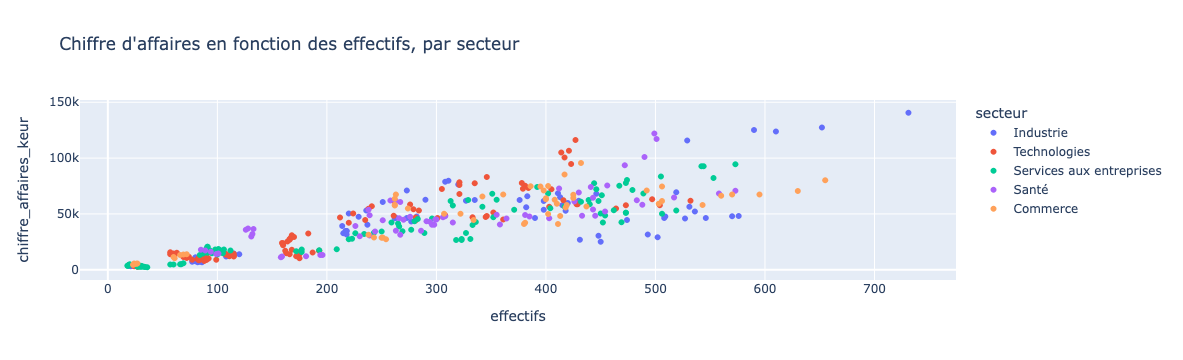

In [18]:
fig = px.scatter(
    df,
    x="effectifs",
    y="chiffre_affaires_keur",
    color="secteur",
    hover_data=["entreprise_id", "annee"],
    title="Chiffre d'affaires en fonction des effectifs, par secteur",
)

fig.show()

- La fonction `px.scatter()` permet de créer un nuage de points.
- `df` indique le `DataFrame` qui contient les données.
- `x="effectifs"` indique la variable à placer sur l'axe `X`.
- `y="chiffre_affaires_keur"` indique la variable à placer sur l'axe `Y`.

Nous représentons donc chaque observation sous la forme : **effectifs → chiffre d'affaires**

- `color="secteur"` demande à Plotly d'utiliser une couleur différente pour chaque valeur de secteur. Nous pouvons ainsi voir immédiatement à quel secteur appartient chaque observation. Plotly ajoute également automatiquement une légende permettant d'identifier les différentes catégories.
- `hover_data=["entreprise_id", "annee"]` indique quelles informations supplémentaires doivent apparaître lorsque l'on survole un point avec la souris. Ainsi, lorsque vous placez votre curseur sur une observation, Plotly peut afficher par exemple :

```
entreprise_id : E001
annee : 2021
effectifs : 610
chiffre_affaires_keur : 123760
secteur : Industrie
```

Cela peut être pratique pour l'exploration des données. Vous pouvez identifier rapidement quelle observation se trouve derrière un point particulier.

- `fig.show()` demande à Plotly d'afficher le graphique. Comme avec Matplotlib, nous avons appelé notre objet graphique `fig`. Mais attention ; il ne s'agit pas exactement du même objet que le `fig` créé avec `fig, ax = plt.subplots()`. Ici, `fig` est un objet Plotly qui contient notre graphique interactif.

### 4.2. Explorer le graphique

Prenez maintenant quelques secondes pour manipuler le graphique.

1. Survolez un point. Placez votre souris sur différents points. Vous devriez voir apparaître les informations associées à l'observation, notamment `entreprise_id` et `annee`.
2. Utilisez la légende. Cliquez sur le nom d'un secteur dans la légende. Plotly masque alors ce secteur. Vous pouvez cliquer à nouveau pour le faire réapparaître.
3. Zoomez. Sélectionnez une zone du graphique avec votre souris pour examiner plus précisément une partie des données. Cela peut être utile lorsqu'un jeu de données contient beaucoup d'observations et que les points sont difficiles à distinguer sur une vue d'ensemble.

**À vous de jouer**

Créons maintenant un graphique interactif qui permet de visualiser l'évolution du chiffre d'affaires moyen au cours du temps. Nous avons déjà préparé ce tableau dans la section consacrée à Matplotlib :

```python
evolution = (
    df.groupby(["annee", "teletravail"])["chiffre_affaires_keur"]
      .mean()
      .unstack()
)
```

Pour utiliser Plotly, il est cependant plus pratique d'avoir les données sous forme de colonnes plutôt que sous forme de tableau avec teletravail en colonnes. Vous pouvez donc commencer par transformer `evolution` :

```python
evolution_plotly = evolution.reset_index()
```

Puis créer votre graphique avec `px.line()`. Ajoutons que :

- l'année doit être sur l'axe `X` ;
- le chiffre d'affaires moyen doit être sur l'axe `Y` ;
- les deux groupes de télétravail doivent être distingués ;
- vous devez ajouter un titre ;
- vous devez rendre le graphique interactif.

**Petit indice**. Vous aurez besoin de `px.line()` et du paramètre `color=...`.


In [19]:
# Votre code ici


## 5. Produire un graphique présentable pour un article

Un graphique utile pour explorer ses données n'est pas forcément adapté pour un mémoire, une thèse ou un article scientifique. Pour ces derniers, il faut veiller à :

- **Avoir une bonne résolution.** Pour un document qui doit être imprimé, il est conseillé d'avoir des images avec une résolution d'environ 300 dpi.
- **Une bonne Lisibilité.** Les titres, labels et légendes doivent rester lisibles lorsque le graphique est réduit dans la mise en page finale.
- **La distinction des groupes.** Ne vous reposez pas uniquement sur les couleurs. Les différents groupes doivent pouvoir être distingués grâce aux styles de lignes, aux marqueurs ou à d'autres éléments visuels. L'objectif est de faciliter la tâche à tous les lecteurs, en prenant en compte ceux qui vont imprimer le document en noir et blanc.

> **À retenir !** Un bon graphique scientifique doit être compréhensible sans que le lecteur ait besoin de votre code pour l'interpréter.

### 5.1. Exporter un graphique matplotlib/seaborn

Reprenons notre graphique sur l'évolution du chiffre d'affaires :


Figure exportée : evolution-ca-moyen-teletravail.png


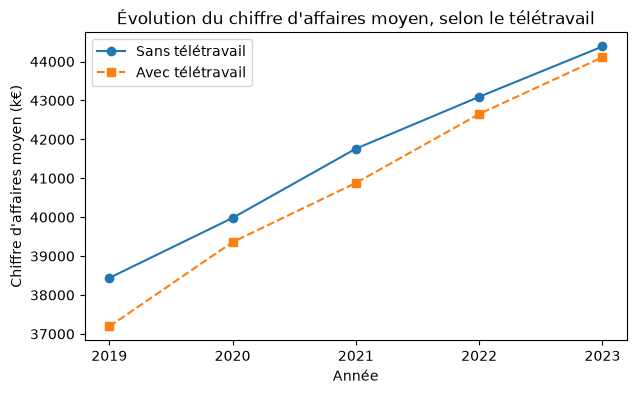

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(evolution.index, evolution[0], marker="o", linestyle="-", label="Sans télétravail")
ax.plot(evolution.index, evolution[1], marker="s", linestyle="--", label="Avec télétravail")

ax.set_xlabel("Année")
ax.set_ylabel("Chiffre d'affaires moyen (k€)")
ax.set_title("Évolution du chiffre d'affaires moyen, selon le télétravail")
ax.legend()

ax.set_xticks(evolution.index)

fig.savefig("evolution-ca-moyen-teletravail.png", dpi=300, bbox_inches="tight")

print("Figure exportée : evolution-ca-moyen-teletravail.png")


Dans le code précédent :

- La méthode `fig.savefig(...)` permet  d'enregistrer la figure dans un fichier.
- `dpi=300` définit la résolution de l'image. Une valeur de 300 dpi est couramment utilisée comme référence pour les figures destinées à l'impression.
- `bbox_inches="tight"` demande à Matplotlib d'ajuster les limites de l'image afin de limiter les espaces inutiles et d'éviter notamment que le titre ou les labels soient coupés.

Dans notre exemple, nous avons également utilisé `linestyle="--"` et `marker="s"` (carré) sur la deuxième courbe. `linestyle="--"` utilise une ligne en pointillés, tandis que `marker="s"` ajoute un marqueur carré. Cela permet de distinguer les deux courbes, même sans la couleur.

### 5.2. PNG, PDF ou SVG ?

Vous pouvez enregistrer votre figure dans différents formats. Le `PNG` est un format d'image matricielle. Il convient très bien pour les présentations, les notebooks et de nombreux usages numériques. Pour une publication scientifique, les formats `PDF` et `SVG` peuvent être particulièrement intéressants, car ils sont vectoriels. De ce fait, la figure reste nette lorsqu'on l'agrandit.

La sauvegarde se fait avec l'instruction : `fig.savefig("evolution-ca-moyen-teletravail.png", dpi=300, bbox_inches="tight")`. Ici, on a enregistré la figure sous le nom `evolution-ca-moyen-teletravail.png`. On pouvait aussi faire `evolution-ca-moyen-teletravail.svg` pour l'enregistrer sous le format `SVG`.

### 5.3. Nettoyer les fichiers créés

Dans notre exemple, nous avons créé un fichier uniquement pour la démonstration. Nous pouvons donc le supprimer à la fin du notebook, avec le code :


In [21]:
import os

if os.path.exists("evolution-ca-moyen-teletravail.png"):
    os.remove("evolution-ca-moyen-teletravail.png")


`os.path.exists()` vérifie que le fichier existe avant d'essayer de le supprimer.


## Le tronc commun est terminé

Avec les modules `00` à `03`, vous disposez maintenant des bases nécessaires pour travailler avec des données de recherche en Python :

- installer et utiliser votre environnement ;
- manipuler les fondamentaux de Python ;
- charger et explorer un jeu de données ;
- sélectionner et filtrer des observations ;
- nettoyer les données ;
- créer et transformer des variables ;
- grouper et comparer des observations ;
- croiser plusieurs jeux de données ;
- manipuler des dates ;
- produire des visualisations ;
- exporter des graphiques pour vos travaux de recherche.

Vous avez également commencé à répondre à notre question de recherche :

> **Est-ce que le télétravail contribue à une meilleure performance des entreprises ?**

Pour l'instant, nous avons essentiellement effectué **une analyse descriptive**. Nous avons observé des différences entre les entreprises pratiquant le télétravail et les autres, mais cela ne suffit pas pour conclure à un effet causal ou même à une différence statistiquement significative.

La suite du cours va justement permettre d'aller plus loin :

- Module 04 : Statistiques. Décrire les données et tester statistiquement les différences et les relations observées.
- Module 05 : Économétrie. Construire des modèles permettant d'étudier plus rigoureusement les relations entre variables.

Les modules suivants permettront ensuite d'aller vers des **analyses avancées, la reproductibilité et des applications spécifiques à la recherche**.


## À vous de jouer

Quatre exercices dans le dossier [`exercices/`](exercices/) :
- **Exercice 1** : reproduire un graphique donné
- **Exercice 2** : personnaliser un graphique (titres, légendes, échelle)
- **Exercice 3** : visualiser une corrélation avec seaborn
- **Exercice 4** : créer un graphique interactif avec plotly

Corrigés disponibles dans [`solutions/03-visualisation/`](../../solutions/03-visualisation/).


## Suite

Consultez la [roadmap](../../docs/roadmap.md) pour choisir votre parcours selon votre objectif de recherche : économétrie, enquêtes, texte, ou machine learning.
